In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


share_link = "https://drive.google.com/file/d/1FrLawxEiamZHo-yYgO9QqfGTDqgiOblP/view?usp=sharing"
file_id = share_link.split('/d/')[1].split('/view')[0]
csv_url = f"https://docs.google.com/uc?export=download&id={"1FrLawxEiamZHo-yYgO9QqfGTDqgiOblP"}"
df = pd.read_csv(csv_url)



In [ ]:
df


In [ ]:
df[['number-people', 'vaccination-rate', 'culling-rate', 'total-infected-ever', 'peak-sick']]

In [14]:
df['outbreak_burden'] = (df['total-infected-ever'] > 0.20 * df['number-people']).astype(int)
df['outbreak_active'] = (df['peak-sick'] > 8).astype(int)

In [5]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total runs: {df.shape[0]}")
print(f"Columns: {list(df.columns)}")
print()

DATASET OVERVIEW
Total runs: 3240
Columns: ['[run number]', 'vaccination-rate', 'culling-rate', 'number-people', 'duration', 'bite-rate', 'infectiousness', 'chance-recover', '[step]', 'total-infected-ever', 'peak-sick', 'count turtles', '%immune', 'outbreak_burden', 'outbreak_active']



In [6]:
print("=" * 50)
print("PARAMETER RANGES")
print("=" * 50)
print(f"vaccination-rate values: {sorted(df['vaccination-rate'].unique())}")
print(f"culling-rate values:     {sorted(df['culling-rate'].unique())}")
print(f"number-people values:    {sorted(df['number-people'].unique())}")
print(f"bite-rate (fixed):       {df['bite-rate'].unique()}")
print(f"infectiousness (fixed):  {df['infectiousness'].unique()}")
print()

PARAMETER RANGES
vaccination-rate values: [np.int64(0), np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(90)]
culling-rate values:     [np.int64(0), np.int64(20), np.int64(40), np.int64(60), np.int64(80), np.int64(90)]
number-people values:    [np.int64(100), np.int64(150), np.int64(200)]
bite-rate (fixed):       [73]
infectiousness (fixed):  [74]



In [8]:
# Total Infected
print("=" * 50)
print("TOTAL INFECTED EVER (exposed + sick, cumulative)")
print("=" * 50)
print(df['total-infected-ever'].describe().round(2))
print()

# Peak Sick
print("=" * 50)
print("PEAK SICK (max simultaneous rabid dogs in any week)")
print("=" * 50)
print(df['peak-sick'].describe().round(2))
print()

TOTAL INFECTED EVER (exposed + sick, cumulative)
count    3240.00
mean       71.17
std        69.22
min         3.00
25%         5.00
50%        50.00
75%       135.00
max       229.00
Name: total-infected-ever, dtype: float64

PEAK SICK (max simultaneous rabid dogs in any week)
count    3240.00
mean        7.08
std         8.26
min         3.00
25%         3.00
50%         3.00
75%         8.00
max        65.00
Name: peak-sick, dtype: float64



In [10]:
C_VAC  = '#2E86AB'   # blue — vaccination
C_CULL = '#E84855'   # red — culling
C_POP  = '#F6AE2D'   # yellow — population
C_BG   = '#F8F9FA'   # light background
C_DARK = '#1A1A2E'

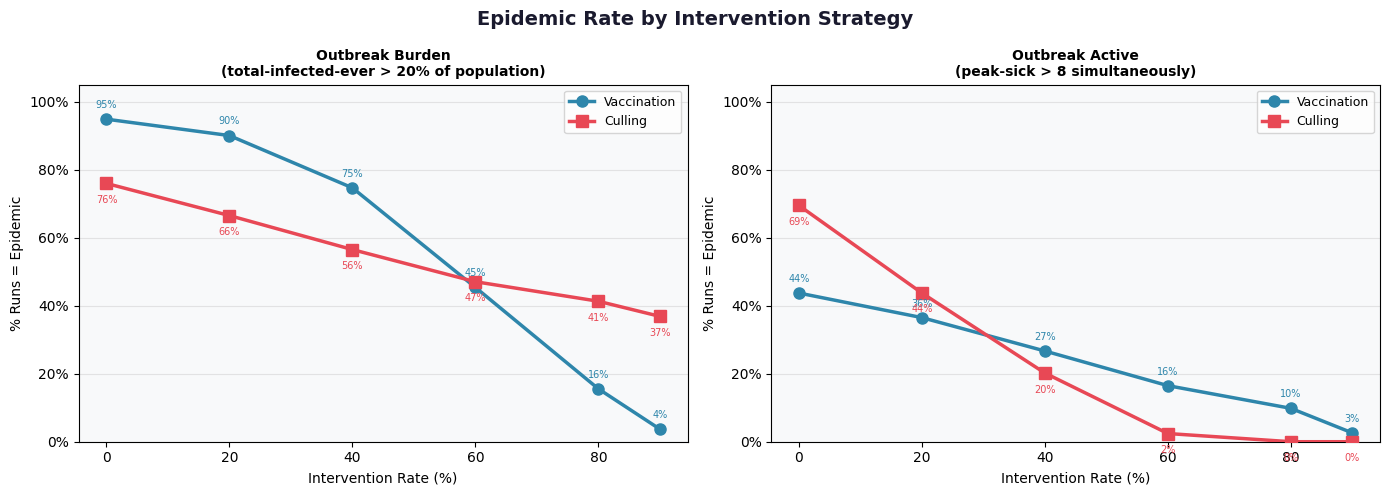

Figure 1 saved.


In [15]:
# FIGURE 1 — Epidemic Rate by Intervention (Line Charts)

fig1, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig1.suptitle('Epidemic Rate by Intervention Strategy',
              fontsize=14, fontweight='bold', color=C_DARK)

for ax, label, title in zip(
    axes,
    ['outbreak_burden', 'outbreak_active'],
    ['Outbreak Burden\n(total-infected-ever > 20% of population)',
     'Outbreak Active\n(peak-sick > 8 simultaneously)']
):
    vax  = df.groupby('vaccination-rate')[label].mean() * 100
    cull = df.groupby('culling-rate')[label].mean() * 100

    ax.plot(vax.index,  vax.values,  'o-', color=C_VAC,  linewidth=2.5,
            markersize=8, label='Vaccination', zorder=3)
    ax.plot(cull.index, cull.values, 's-', color=C_CULL, linewidth=2.5,
            markersize=8, label='Culling',     zorder=3)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Intervention Rate (%)', fontsize=10)
    ax.set_ylabel('% Runs = Epidemic',     fontsize=10)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    ax.set_facecolor(C_BG)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 105)

    # Annotate each point
    for x, y in zip(vax.index, vax.values):
        ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color=C_VAC)
    for x, y in zip(cull.index, cull.values):
        ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points',
                    xytext=(0, -14), ha='center', fontsize=7, color=C_CULL)

plt.tight_layout()
plt.savefig('fig1_epidemic_rate_lines.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")



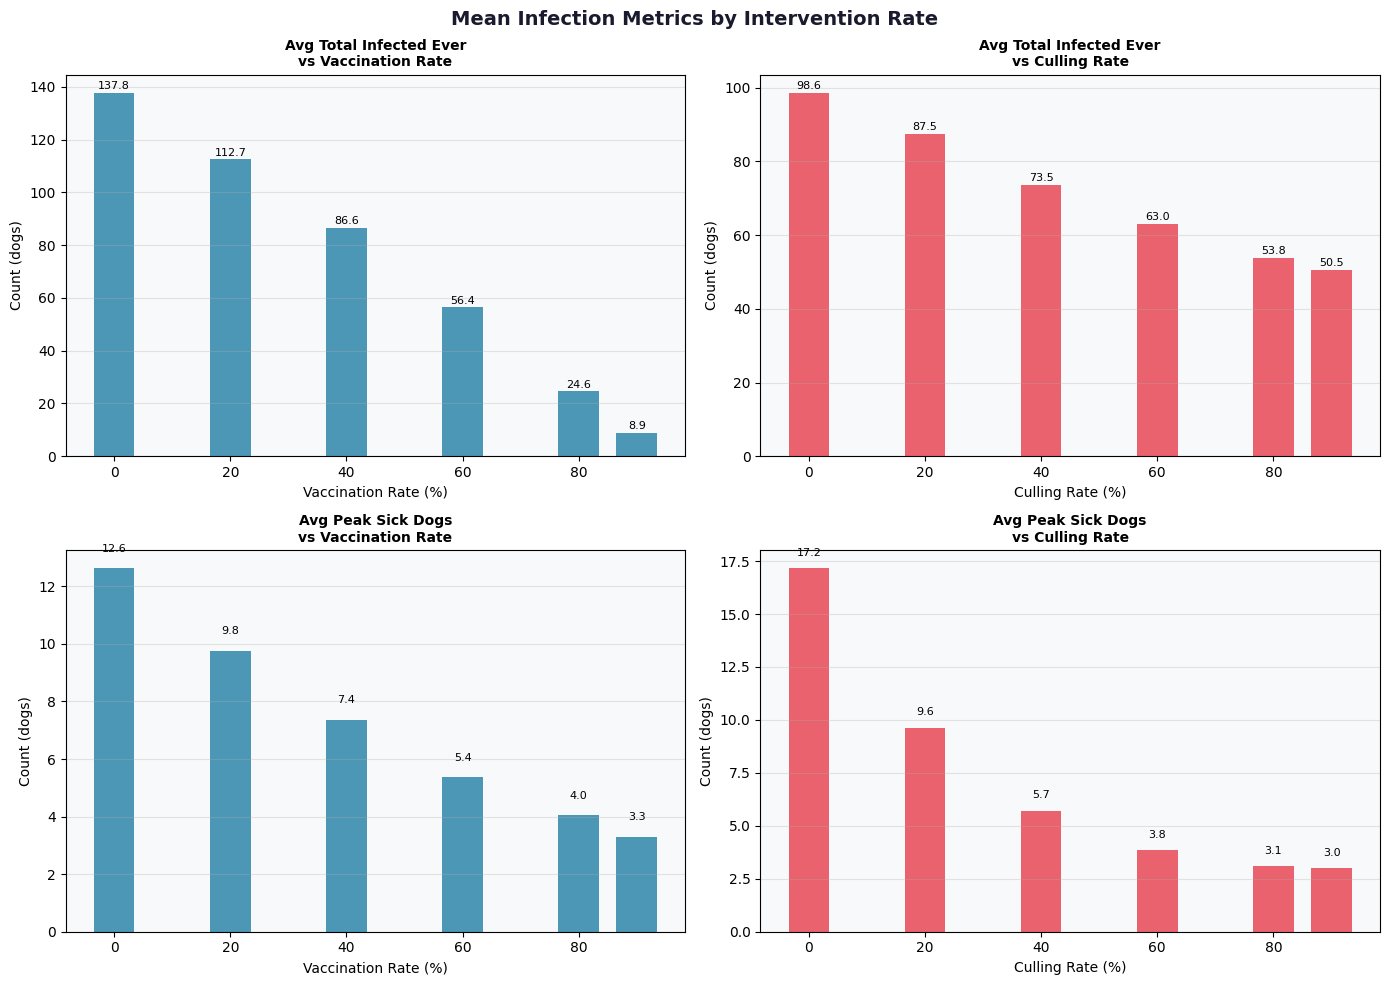

Figure 2 saved.


In [16]:
# FIGURE 2 — Mean Total Infected & Peak Sick (Bar Charts)
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
fig2.suptitle('Mean Infection Metrics by Intervention Rate',
              fontsize=14, fontweight='bold', color=C_DARK)

datasets = [
    (axes2[0,0], 'vaccination-rate', 'total-infected-ever', C_VAC,
     'Avg Total Infected Ever\nvs Vaccination Rate', 'Vaccination Rate (%)'),
    (axes2[0,1], 'culling-rate',     'total-infected-ever', C_CULL,
     'Avg Total Infected Ever\nvs Culling Rate',     'Culling Rate (%)'),
    (axes2[1,0], 'vaccination-rate', 'peak-sick',           C_VAC,
     'Avg Peak Sick Dogs\nvs Vaccination Rate',      'Vaccination Rate (%)'),
    (axes2[1,1], 'culling-rate',     'peak-sick',           C_CULL,
     'Avg Peak Sick Dogs\nvs Culling Rate',          'Culling Rate (%)'),
]

for ax, groupby, metric, color, title, xlabel in datasets:
    data = df.groupby(groupby)[metric].mean()
    bars = ax.bar(data.index, data.values, color=color, alpha=0.85, width=7)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Count (dogs)', fontsize=10)
    ax.set_facecolor(C_BG)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_mean_metrics_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")



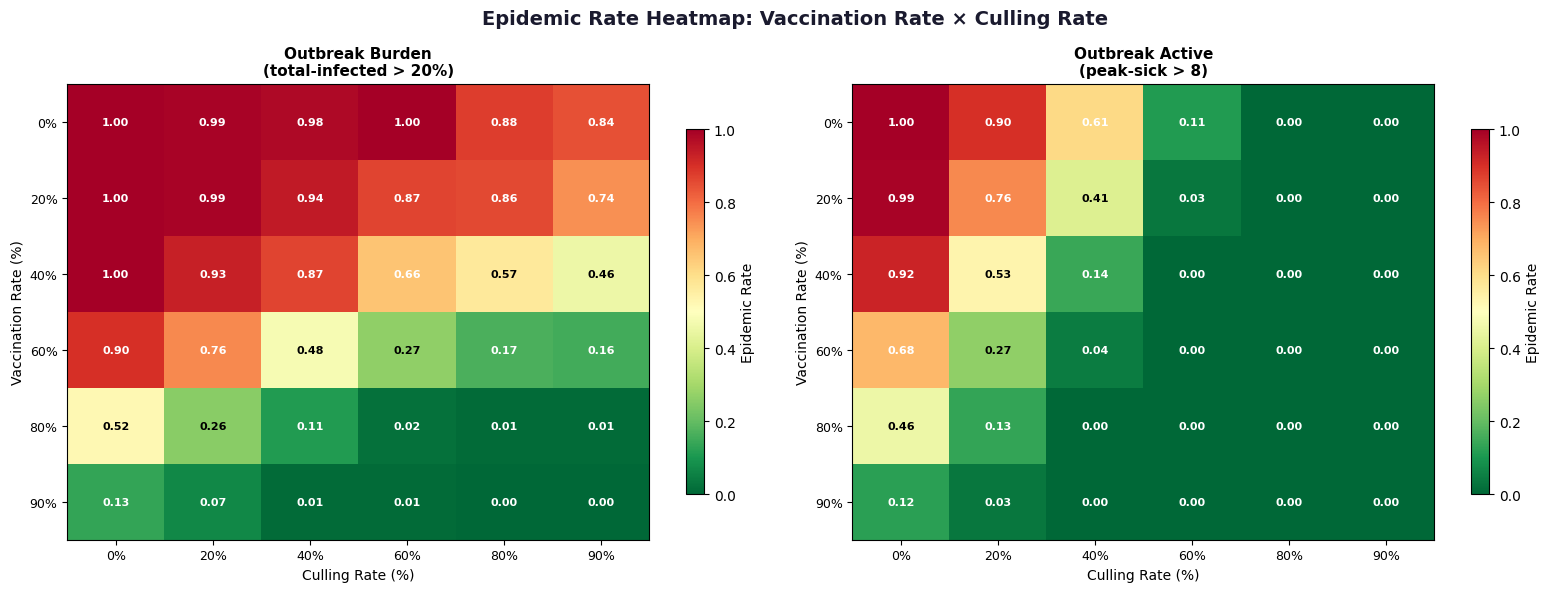

Figure 3 saved.


In [17]:
# FIGURE 3 — Heatmaps: Vaccination x Culling

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
fig3.suptitle('Epidemic Rate Heatmap: Vaccination Rate × Culling Rate',
              fontsize=14, fontweight='bold', color=C_DARK)

for ax, label, title in zip(
    axes3,
    ['outbreak_burden', 'outbreak_active'],
    ['Outbreak Burden\n(total-infected > 20%)',
     'Outbreak Active\n(peak-sick > 8)']
):
    pivot = df.groupby(['vaccination-rate', 'culling-rate'])[label].mean().unstack()
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{c}%' for c in pivot.columns], fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{r}%' for r in pivot.index], fontsize=9)
    ax.set_xlabel('Culling Rate (%)',     fontsize=10)
    ax.set_ylabel('Vaccination Rate (%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Epidemic Rate')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            text_color = 'white' if val > 0.6 or val < 0.2 else 'black'
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color=text_color)

plt.tight_layout()
plt.savefig('fig3_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")



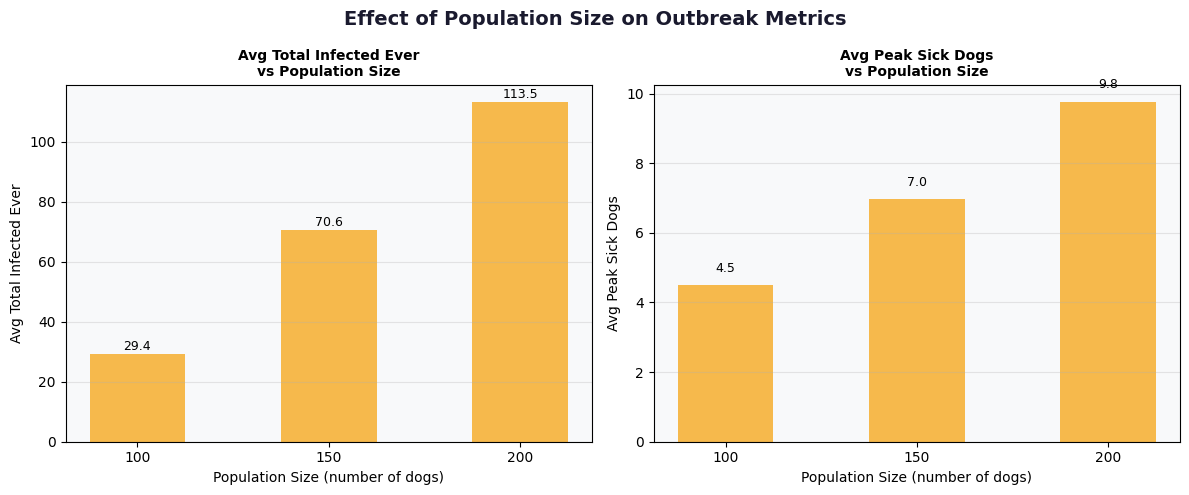

Figure 4 saved.


In [18]:
# FIGURE 4 — Population Size Effect

fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')
fig4.suptitle('Effect of Population Size on Outbreak Metrics',
              fontsize=14, fontweight='bold', color=C_DARK)

for ax, metric, ylabel in zip(
    axes4,
    ['total-infected-ever', 'peak-sick'],
    ['Avg Total Infected Ever', 'Avg Peak Sick Dogs']
):
    data = df.groupby('number-people')[metric].mean()
    bars = ax.bar(data.index.astype(str), data.values,
                  color=C_POP, alpha=0.85, width=0.5)
    ax.set_xlabel('Population Size (number of dogs)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{ylabel}\nvs Population Size', fontweight='bold', fontsize=10)
    ax.set_facecolor(C_BG)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig4_population_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")



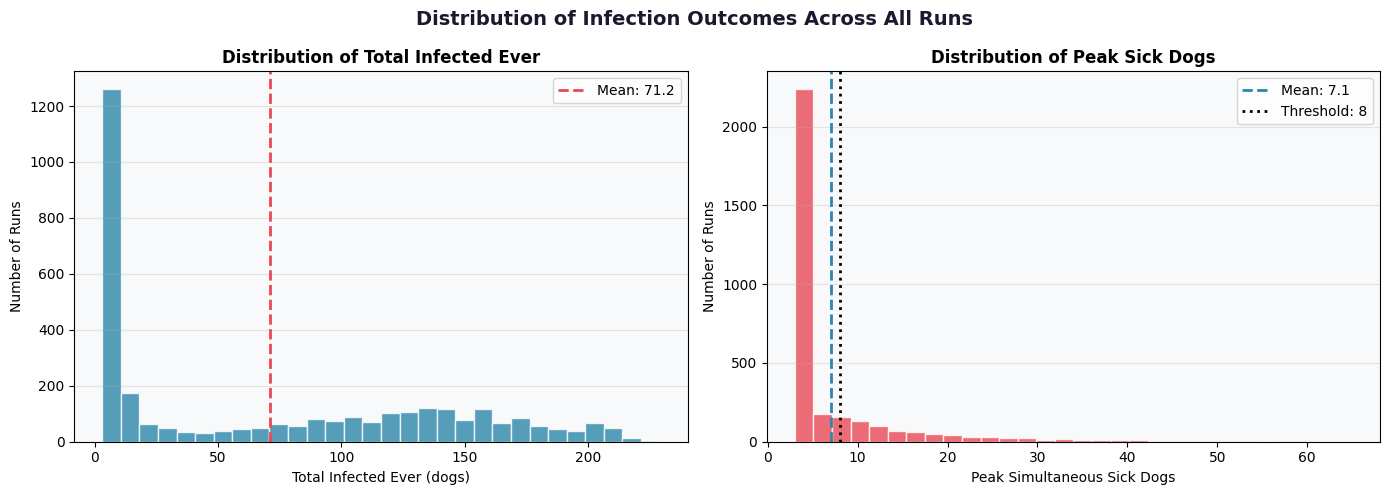

Figure 5 saved.

All figures saved!
Files: fig1_epidemic_rate_lines.png
       fig2_mean_metrics_bars.png
       fig3_heatmaps.png
       fig4_population_effect.png
       fig5_distributions.png


In [19]:
# FIGURE 5 — Distribution of total-infected-ever

fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig5.suptitle('Distribution of Infection Outcomes Across All Runs',
              fontsize=14, fontweight='bold', color=C_DARK)

# Histogram of total-infected-ever
axes5[0].hist(df['total-infected-ever'], bins=30, color=C_VAC,
              alpha=0.8, edgecolor='white')
axes5[0].axvline(df['total-infected-ever'].mean(), color=C_CULL,
                 linestyle='--', linewidth=2,
                 label=f"Mean: {df['total-infected-ever'].mean():.1f}")
axes5[0].set_title('Distribution of Total Infected Ever', fontweight='bold')
axes5[0].set_xlabel('Total Infected Ever (dogs)')
axes5[0].set_ylabel('Number of Runs')
axes5[0].set_facecolor(C_BG)
axes5[0].legend()
axes5[0].grid(axis='y', alpha=0.3)

# Histogram of peak-sick
axes5[1].hist(df['peak-sick'], bins=30, color=C_CULL,
              alpha=0.8, edgecolor='white')
axes5[1].axvline(df['peak-sick'].mean(), color=C_VAC,
                 linestyle='--', linewidth=2,
                 label=f"Mean: {df['peak-sick'].mean():.1f}")
axes5[1].axvline(8, color='black', linestyle=':', linewidth=2,
                 label='Threshold: 8')
axes5[1].set_title('Distribution of Peak Sick Dogs', fontweight='bold')
axes5[1].set_xlabel('Peak Simultaneous Sick Dogs')
axes5[1].set_ylabel('Number of Runs')
axes5[1].set_facecolor(C_BG)
axes5[1].legend()
axes5[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

print("\nAll figures saved!")
print("Files: fig1_epidemic_rate_lines.png")
print("       fig2_mean_metrics_bars.png")
print("       fig3_heatmaps.png")
print("       fig4_population_effect.png")
print("       fig5_distributions.png")